In [1]:
import cv2
from insightface.app import FaceAnalysis
import torch
import numpy as np
from PIL import Image

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))


def compare_face_insight(img1, img2):
    try:
        image = np.array(img1.convert("RGB"))[:,:,::-1]
        faces = app.get(image)
        faceid_embeds_1 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        image = np.array(img2.convert("RGB"))[:,:,::-1]
        faces = app.get(image)
        faceid_embeds_2 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        cos_sim = torch.nn.functional.cosine_similarity(faceid_embeds_1, faceid_embeds_2).item()
        return cos_sim
    except Exception as e:
        print("Error in compare_face_insight:", e)
        return None



Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], w

In [2]:
import os
root = '/path/to/casia-webface'

val_ids = []
with open("./index.txt","r") as f:
    lines = f.readlines()
    for line in lines:
        filename, split = line.strip().split()
        if split != "train":
            val_ids.append(filename.split("/")[0])
val_ids = list(set(val_ids))

In [3]:
sims = []
import tqdm
import random
bar = tqdm.tqdm(val_ids + val_ids)
for id in bar:
    if len(os.listdir(os.path.join(root, id))) < 2:
        continue

    files = os.listdir(os.path.join(root, id))
    file_0 = files[0]
    file_1 = random.choice(files[1:])
    img1_path = os.path.join(root, id, file_0)   
    img2_path = os.path.join(root, id, file_1)
    img1 = Image.open(img1_path)
    img2 = Image.open(img2_path)
    sim = compare_face_insight(img1, img2)
    if sim is not None:
        sims.append(sim)
    bar.set_description(f"avg sim: {np.mean(sims):.4f}, avg sim (filtered): {np.mean([s for s in sims if s>0.3]):.4f}")

avg sim: 0.4986, avg sim (filtered): 0.5620:  19%|█▉        | 815/4230 [00:50<03:09, 18.00it/s]

Error in compare_face_insight: list index out of range


avg sim: 0.5033, avg sim (filtered): 0.5671:  36%|███▌      | 1522/4230 [01:18<01:41, 26.75it/s]

Error in compare_face_insight: list index out of range


avg sim: 0.5012, avg sim (filtered): 0.5695: 100%|██████████| 4230/4230 [02:43<00:00, 25.85it/s]


In [15]:
import pickle
with open("res_fracface.pkl","rb") as f:
    fracface_sims = pickle.load(f)

with open("res_minusface.pkl","rb") as f:
    minusface_sims = pickle.load(f)

Text(0.5, 0, 'Cosine Similarity')

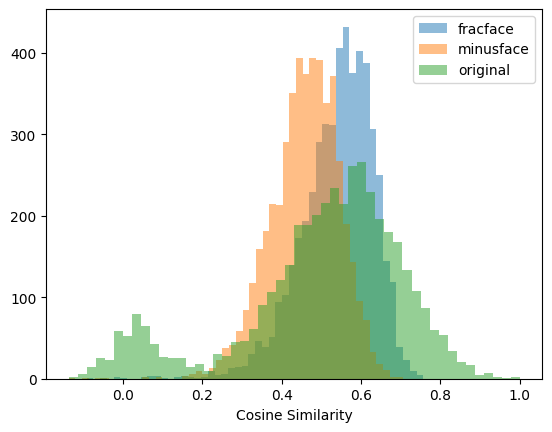

In [17]:
import pylab
pylab.hist(fracface_sims['sims'], bins=50, alpha=0.5, label='fracface')
pylab.hist(minusface_sims['sims'], bins=50, alpha=0.5, label='minusface')
pylab.hist(sims, bins=50, alpha=0.5, label='original')
pylab.legend()
pylab.xlabel("Cosine Similarity")

In [32]:
import pickle
with open("../../attacks/minusface/test.pkl", "rb") as f:
    pre_loaded_teachers = pickle.load(f)

with open("./test.pkl", "rb") as f:
    pre_loaded_teachers_partial = pickle.load(f)

In [ ]:
pre_loaded_teachers_partial["filenames"][0][0] zhegeshunxuhaishibuyiyangdesbadanshimeishi

'/path/to/lfw/John_Ashcroft/John_Ashcroft_0010.jpg'

In [ ]:
a = set(sum(pre_loaded_teachers["filenames"], []))
b = set(sum(pre_loaded_teachers_partial["filenames"], []))


set()

In [29]:
import os
paths = []
root = "/path/to/lfw"
for id in os.listdir(root):
    id_folder = os.path.join(root, id)
    if not os.path.isdir(id_folder):
        continue
    for file in os.listdir(id_folder):
        if file.endswith(".jpg"):
            paths.append(os.path.join(id_folder, file))

In [30]:
paths = sorted(paths)
import random
random.seed(42)
random.shuffle(paths)
paths[0]

'/path/to/lfw/Rose_Linkins/Rose_Linkins_0001.jpg'

In [5]:
import random
paths = []
with open("/path/to/lfw/lfw_ann.txt", "r") as f:
    for line in f.readlines():
        line = line.strip().split(" ")
        if line[0] != "1":
            continue
        img1 = "/path/to/lfw/" + line[1]
        img2 = "/path/to/lfw/" + line[2]
        paths.extend([img1, img2])

paths = sorted(paths)
random.seed(42)
random.shuffle(paths) 

In [7]:
paths[1]

'/path/to/lfw/lfw_112x112/8869.bmp'